In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv(r'F:\ICT\ICT DSA\dataset\Wine_clust.csv')
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [4]:
print("\nMissing Values :")
data.isnull().sum()
#This dataset has no missing values.


Missing Values :


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [5]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
scaled_data = std_scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data,columns =data.columns)
scaled_data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [6]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components = 4) 
pca1.fit(scaled_data)
x_pca1 = pca1.transform(scaled_data)
x_pca1.shape

(178, 4)

In [7]:
#how much % info retained
np.cumsum(pca1.explained_variance_ratio_)
#check last number 73%  info retained

array([0.36198848, 0.55406338, 0.66529969, 0.73598999])

In [8]:
print("Variance retained:",
      np.cumsum(pca1.explained_variance_ratio_)[-1]*100)
# PCA reduced 13 features to 4 principal components while retaining approximately 74% of the information.

Variance retained: 73.59899907589929


###  K Means

In [9]:
from sklearn.cluster import KMeans
wcss = [] 
for i in range(2,10):
    k_means = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    k_means.fit(x_pca1)
    wcss.append(k_means.inertia_)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

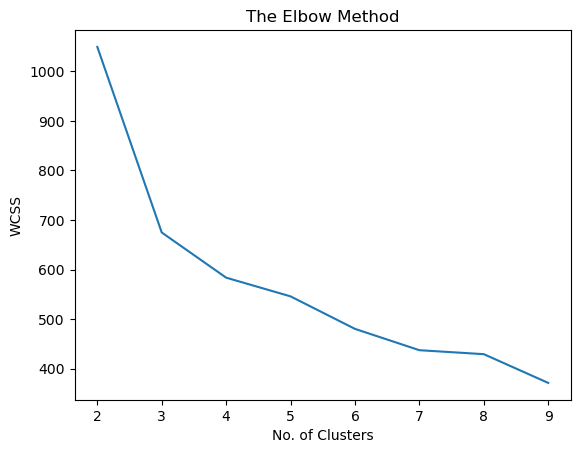

In [10]:
plt.plot(range(2,10),wcss)
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
k_means = KMeans(n_clusters = 3, init = 'k-means++',random_state = 42)
#n_clusters = 3 by referring the elbow method.
y_kmeans1 = k_means.fit_predict(x_pca1)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [12]:
from sklearn.metrics import silhouette_score
sil_scores = []
for i in range(2,10):
    k_means = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    y_kmeans = k_means.fit_predict(x_pca1)
    s_score = silhouette_score(x_pca1,y_kmeans)
    sil_scores.append(s_score)
sil_scores

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

[0.35305420272870847,
 0.4050568527010295,
 0.36543630746801165,
 0.30093816421830594,
 0.26307351199360984,
 0.24787307879133116,
 0.21529166607030067,
 0.2456630894937722]

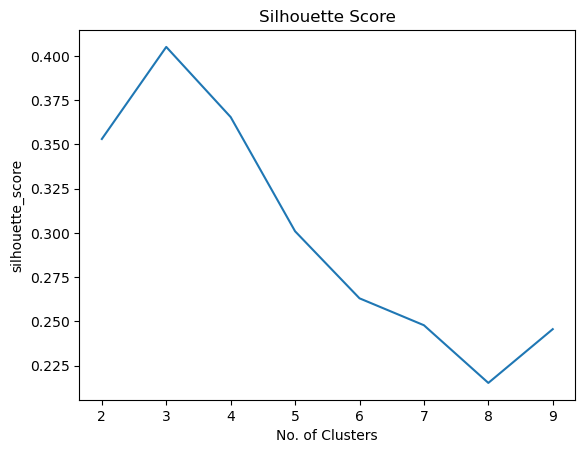

Optimal K = 3


In [13]:
x = range(2,10)
plt.plot(x,sil_scores)
plt.title('Silhouette Score')
plt.xlabel('No. of Clusters')
plt.ylabel('silhouette_score')
plt.show()
best_k = np.argmax(sil_scores) + 2
print("Optimal K =",best_k)

In [14]:
### Final K Means model after analysing sil_scores, Optimal number of clusters is 3
kmeans_final = KMeans(n_clusters=best_k,random_state=42,n_init=10)
kmeans_labels = kmeans_final.fit_predict(x_pca1)
print("KMeans Silhouette Score:",
      silhouette_score(x_pca1,kmeans_labels))

KMeans Silhouette Score: 0.406596910894866


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


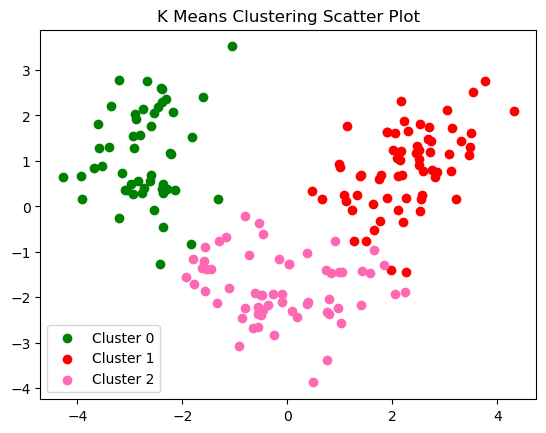

In [15]:
colors = ['g','r','hotpink','cyan','brown']
for i in range(3):
    plt.scatter(x_pca1[kmeans_labels == i, 0],x_pca1[kmeans_labels == i, 1],c=colors[i], label=f'Cluster {i}')
plt.title("K Means Clustering Scatter Plot")
plt.legend()

### AHC 

In [16]:
from sklearn.cluster import AgglomerativeClustering
sil_scores_ahc = []
for i in range(2,10):
    ahc = AgglomerativeClustering(n_clusters = i, metric = 'euclidean',linkage = 'ward')
    #Ward - gives compact clusters. Mainly used for numercal datatypes gives best result.
    y_ahc = ahc.fit_predict(x_pca1)
    s_score_ahc = silhouette_score(x_pca1,y_ahc)
    sil_scores_ahc.append(s_score_ahc)

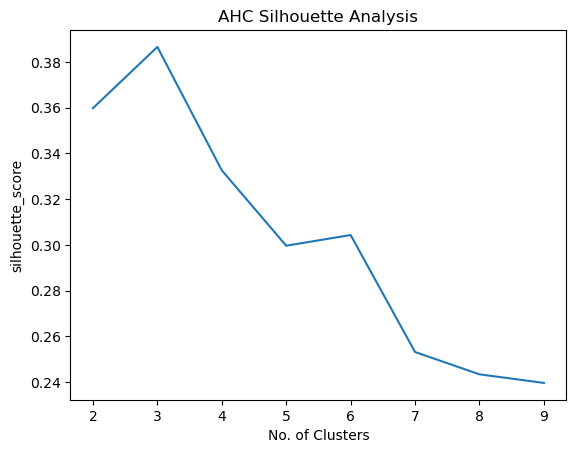

In [17]:
x = range(2,10)
plt.plot(x,sil_scores_ahc)
plt.title('AHC Silhouette Analysis')
plt.xlabel('No. of Clusters')
plt.ylabel('silhouette_score')
plt.show()

In [18]:
best_k_ahc = np.argmax(sil_scores_ahc) + 2
print("Optimal Clusters =",best_k_ahc)
#From this AHC Silhouette Analysis, Optimal cluster is 3

Optimal Clusters = 3


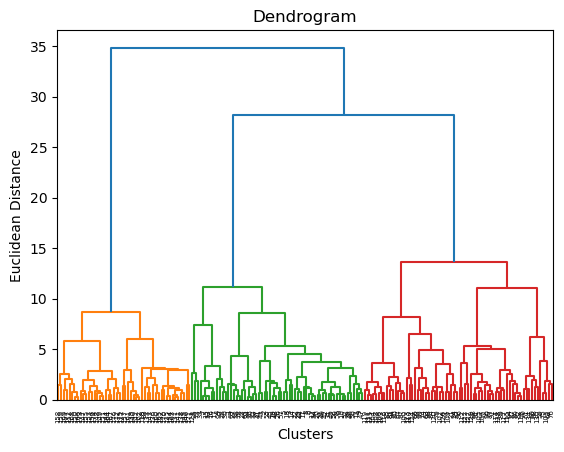

In [19]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(x_pca1, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Clusters')
plt.ylabel('Euclidean Distance')
plt.show()

In [20]:
#  Build linkage matrix
Z = sch.linkage(x_pca1, method='ward')
#  Extract merge distances from the 3rd column, ie 0,1,2.
distances = Z[:, 2]
#  Compute second derivative (acceleration)
acceleration = np.diff(distances, 2)
#  Locate maximum acceleration
idx = np.argmax(acceleration)

#  Compute optimal number of clusters
n_samples = x_pca1.shape[0]
optimal_k = n_samples - (idx + 2)

print("Suggested number of clusters:", optimal_k)

Suggested number of clusters: 3


In [21]:
ahc_final = AgglomerativeClustering(n_clusters=best_k_ahc,linkage='ward')
ahc_labels = ahc_final.fit_predict(x_pca1)
print("AHC Silhouette Score:",silhouette_score(x_pca1,ahc_labels))

AHC Silhouette Score: 0.3865188566384044


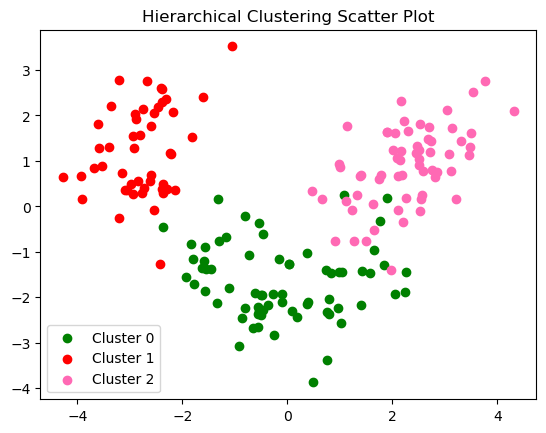

In [22]:
colors = ['g','r','hotpink','cyan','brown']
for i in range(3):
    plt.scatter(x_pca1[ahc_labels == i, 0],x_pca1[ahc_labels == i, 1], c=colors[i],label=f'Cluster {i}')
plt.title("Hierarchical Clustering Scatter Plot")
plt.legend()

### DBSCAN

In [23]:
from sklearn.cluster import DBSCAN
dbs= DBSCAN(eps=1,min_samples = 9)
dbscan_labels  = dbs.fit_predict(x_pca1)
np.unique(dbscan_labels )

array([-1,  0,  1,  2])

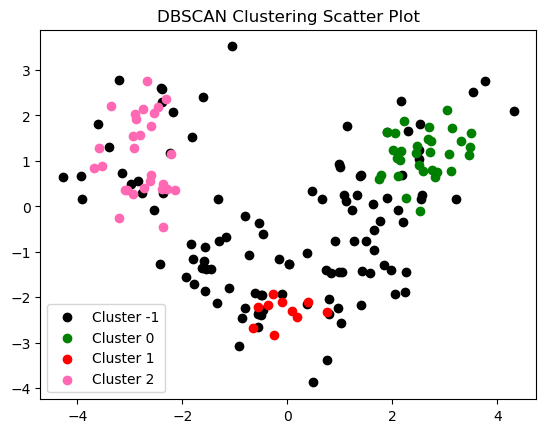

In [24]:
colors = {-1:'black',0:'green',1:'red',2:'hotpink'}
for i in np.unique(dbscan_labels):
    plt.scatter(x_pca1[dbscan_labels  == i, 0],x_pca1[dbscan_labels  == i, 1], c=colors[i],label=f'Cluster {i}')
plt.title("DBSCAN Clustering Scatter Plot")
plt.legend()

In [25]:
#K-Means
#Elbow Method suggests 3 clusters.
#Silhouette Analysis confirms 3 clusters.
#Final model built with 3 clusters.

In [26]:
#Agglomerative Clustering
#Dendrogram and Silhouette Analysis suggest 3 clusters.
#Final model built with 3 clusters.

In [27]:
#DBSCAN
#Using eps=1 and min_samples=9, DBSCAN identified 3 clusters and some noise points.
#Final model built.